In [ ]:
# ============================================================
# PROJET DEEP LEARNING — PARTIE I : MLP
# Dataset : Breast Cancer Wisconsin
# ============================================================

# --- Imports ---

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Fixer les seeds pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")


Device utilisé : cpu


In [ ]:
# ============================================================
# ÉTAPE 2 — Chargement et exploration du dataset
# ============================================================

# Charger le dataset Breast Cancer Wisconsin
data = load_breast_cancer()

# Convertir en DataFrame pour mieux visualiser
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# --- Infos générales ---
print("=== INFOS GÉNÉRALES ===")
print(f"Nombre d'échantillons : {df.shape[0]}")
print(f"Nombre de features    : {df.shape[1] - 1}")
print(f"\nClasses : {data.target_names}")
print(f"Distribution des classes :")
print(df['target'].value_counts())
print(f"\nValeurs manquantes : {df.isnull().sum().sum()}")

# --- Statistiques descriptives ---
print("\n=== STATISTIQUES DESCRIPTIVES ===")
print(df.describe().round(2))

=== INFOS GÉNÉRALES ===
Nombre d'échantillons : 569
Nombre de features    : 30

Classes : ['malignant' 'benign']
Distribution des classes :
target
1    357
0    212
Name: count, dtype: int64

Valeurs manquantes : 0

=== STATISTIQUES DESCRIPTIVES ===
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean

In [ ]:
# ============================================================
# ÉTAPE 3 — Préparation des données
# ============================================================

# --- Séparation features / cible ---
X = data.data
y = data.target

# --- Split Train / Validation / Test ---
# D'abord : 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ensuite : 75% train, 25% val (sur le 80% restant → 60% / 20% final)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("=== TAILLES DES ENSEMBLES ===")
print(f"Train      : {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation : {X_val.shape[0]} échantillons ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test       : {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

# --- Normalisation (StandardScaler) ---
# IMPORTANT : on fitte UNIQUEMENT sur le train pour éviter le data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform sur train
X_val   = scaler.transform(X_val)        # transform seulement sur val
X_test  = scaler.transform(X_test)       # transform seulement sur test

print("\n=== NORMALISATION ===")
print(f"Moyenne train (doit être ≈ 0) : {X_train.mean():.4f}")
print(f"Std train    (doit être ≈ 1) : {X_train.std():.4f}")

# --- Conversion en Tenseurs PyTorch ---
X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)

y_train_t = torch.FloatTensor(y_train).to(device)
y_val_t   = torch.FloatTensor(y_val).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

print("\n=== TENSEURS PYTORCH ===")
print(f"X_train_t shape : {X_train_t.shape}")
print(f"y_train_t shape : {y_train_t.shape}")
print(f"Type            : {X_train_t.dtype}")


=== TAILLES DES ENSEMBLES ===
Train      : 341 échantillons (60%)
Validation : 114 échantillons (20%)
Test       : 114 échantillons (20%)

=== NORMALISATION ===
Moyenne train (doit être ≈ 0) : -0.0000
Std train    (doit être ≈ 1) : 1.0000

=== TENSEURS PYTORCH ===
X_train_t shape : torch.Size([341, 30])
y_train_t shape : torch.Size([341])
Type            : torch.float32


In [ ]:
# ============================================================
# ÉTAPE 4 — Implémentation du MLP (2 versions)
# ============================================================

# ── VERSION 1 : nn.Sequential ──────────────────────────────
# Simple et rapide, on empile les couches comme une liste

mlp_sequential = nn.Sequential(
    nn.Linear(30, 128),   # Couche entrée : 30 features → 128 neurones
    nn.ReLU(),            # Activation
    nn.BatchNorm1d(128),  # Normalisation du batch
    nn.Dropout(0.3),      # Régularisation : désactive 30% des neurones

    nn.Linear(128, 64),   # Couche cachée 1 : 128 → 64
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),

    nn.Linear(64, 32),    # Couche cachée 2 : 64 → 32
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.3),

    nn.Linear(32, 1)      # Couche sortie : 32 → 1 (classification binaire)
    # Pas de Sigmoid ici ! BCEWithLogitsLoss l'applique automatiquement
).to(device)

print("=== VERSION 1 : nn.Sequential ===")
print(mlp_sequential)


# ── VERSION 2 : Classe personnalisée ──────────────────────
# Plus flexible, c'est comme ça que les vrais projets sont faits

class MLPPersonnalise(nn.Module):

    def __init__(self, input_size=30):
        super(MLPPersonnalise, self).__init__()

        # On définit les couches comme attributs
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)

        self.fc4 = nn.Linear(32, 1)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # forward() définit comment les données traversent le réseau

        x = self.dropout(self.bn1(self.relu(self.fc1(x))))  # Bloc 1
        x = self.dropout(self.bn2(self.relu(self.fc2(x))))  # Bloc 2
        x = self.dropout(self.bn3(self.relu(self.fc3(x))))  # Bloc 3
        x = self.fc4(x)                                     # Sortie
        return x

# Instancier le modèle personnalisé
mlp_custom = MLPPersonnalise(input_size=30).to(device)

print("\n=== VERSION 2 : Classe Personnalisée ===")
print(mlp_custom)

# --- Compter le nombre de paramètres ---
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nNombre de paramètres (Sequential)   : {count_params(mlp_sequential):,}")
print(f"Nombre de paramètres (Personnalisé) : {count_params(mlp_custom):,}")

=== VERSION 1 : nn.Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): ReLU()
  (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): ReLU()
  (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

=== VERSION 2 : Classe Personnalisée ===
MLPPersonnalise(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1

In [ ]:
# ============================================================
# ÉTAPE 5 — Inspection des paramètres du modèle (corrigé)
# ============================================================

print("=== named_parameters() — Tous les paramètres du modèle ===\n")
for name, param in mlp_custom.named_parameters():
    # Aplatir le tenseur pour afficher les 3 premières valeurs
    valeurs = param.data.flatten()[:3]
    print(f"Nom      : {name}")
    print(f"Shape    : {param.shape}")
    print(f"Exemple  : {valeurs}...")
    print("-" * 50)

print("\n=== state_dict() — Dictionnaire des poids ===\n")
state = mlp_custom.state_dict()
print("Clés disponibles dans le state_dict :")
for key in state.keys():
    print(f"  → {key} | shape : {state[key].shape}")

=== named_parameters() — Tous les paramètres du modèle ===

Nom      : fc1.weight
Shape    : torch.Size([128, 30])
Exemple  : tensor([0.0503, 0.1430, 0.0622])...
--------------------------------------------------
Nom      : fc1.bias
Shape    : torch.Size([128])
Exemple  : tensor([0.0335, 0.0776, 0.1808])...
--------------------------------------------------
Nom      : bn1.weight
Shape    : torch.Size([128])
Exemple  : tensor([1., 1., 1.])...
--------------------------------------------------
Nom      : bn1.bias
Shape    : torch.Size([128])
Exemple  : tensor([0., 0., 0.])...
--------------------------------------------------
Nom      : fc2.weight
Shape    : torch.Size([64, 128])
Exemple  : tensor([-0.0020,  0.0876, -0.0780])...
--------------------------------------------------
Nom      : fc2.bias
Shape    : torch.Size([64])
Exemple  : tensor([0.0519, 0.0570, 0.0809])...
--------------------------------------------------
Nom      : bn2.weight
Shape    : torch.Size([64])
Exemple  : tenso

=== COMPARAISON DES INITIALISATIONS (poids fc1) ===

Gaussienne — mean: 0.0004 | std: 0.0101 | min: -0.0368 | max: 0.0341
Constante  — mean: 0.0100 | std: 0.0000 | min: 0.0100 | max: 0.0100
Xavier     — mean: 0.0003 | std: 0.1118 | min: -0.1948 | max: 0.1948


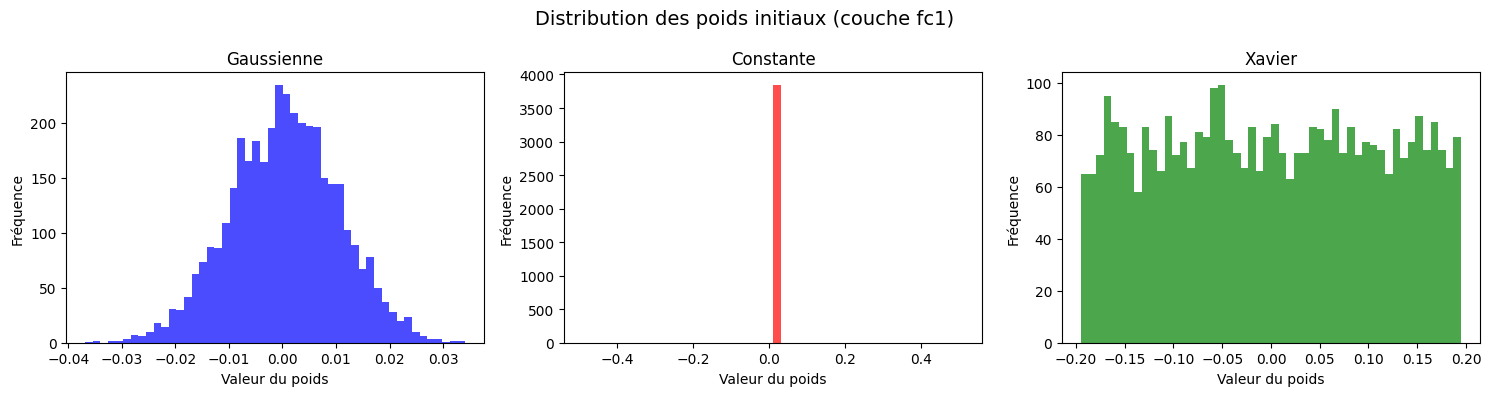


=== POURQUOI XAVIER EST LA MEILLEURE INITIALISATION ? ===
Gaussienne : std=0.01 → poids trop petits → gradients qui disparaissent
Constante  : std=0.00 → tous identiques → symétrie → le modèle n'apprend pas
Xavier     : std calculée selon la taille des couches → gradients stables ✅


In [ ]:
# ============================================================
# ÉTAPE 6 — Stratégies d'initialisation des poids
# ============================================================

def initialiser_modele(modele, strategie='xavier'):
    """Applique une stratégie d'initialisation à toutes les couches Linear"""
    for module in modele.modules():
        if isinstance(module, nn.Linear):
            if strategie == 'gaussienne':
                # Initialisation gaussienne : poids tirés d'une loi normale
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.zeros_(module.bias)

            elif strategie == 'constante':
                # Initialisation constante : tous les poids à 0.01
                nn.init.constant_(module.weight, 0.01)
                nn.init.zeros_(module.bias)

            elif strategie == 'xavier':
                # Initialisation Xavier : meilleure pour ReLU/tanh
                # Formule : std = sqrt(2 / (fan_in + fan_out))
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    return modele


# --- Créer 3 modèles avec 3 initialisations différentes ---
model_gaussien  = initialiser_modele(MLPPersonnalise().to(device), 'gaussienne')
model_constant  = initialiser_modele(MLPPersonnalise().to(device), 'constante')
model_xavier    = initialiser_modele(MLPPersonnalise().to(device), 'xavier')

# --- Vérifier les poids de fc1 pour chaque stratégie ---
print("=== COMPARAISON DES INITIALISATIONS (poids fc1) ===\n")

w_g = model_gaussien.fc1.weight.data.flatten()
w_c = model_constant.fc1.weight.data.flatten()
w_x = model_xavier.fc1.weight.data.flatten()

print(f"Gaussienne — mean: {w_g.mean():.4f} | std: {w_g.std():.4f} | min: {w_g.min():.4f} | max: {w_g.max():.4f}")
print(f"Constante  — mean: {w_c.mean():.4f} | std: {w_c.std():.4f} | min: {w_c.min():.4f} | max: {w_c.max():.4f}")
print(f"Xavier     — mean: {w_x.mean():.4f} | std: {w_x.std():.4f} | min: {w_x.min():.4f} | max: {w_x.max():.4f}")

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution des poids initiaux (couche fc1)", fontsize=14)

for ax, weights, titre, couleur in zip(
    axes,
    [w_g, w_c, w_x],
    ['Gaussienne', 'Constante', 'Xavier'],
    ['blue', 'red', 'green']
):
    ax.hist(weights.numpy(), bins=50, color=couleur, alpha=0.7)
    ax.set_title(titre)
    ax.set_xlabel("Valeur du poids")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

print("\n=== POURQUOI XAVIER EST LA MEILLEURE INITIALISATION ? ===")
print("Gaussienne : std=0.01 → poids trop petits → gradients qui disparaissent")
print("Constante  : std=0.00 → tous identiques → symétrie → le modèle n'apprend pas")
print("Xavier     : std calculée selon la taille des couches → gradients stables ✅")


In [ ]:
# ============================================================
# ÉTAPE 7 — Entraînement du modèle (initialisation Xavier)
# ============================================================

from torch.utils.data import TensorDataset, DataLoader

# --- DataLoaders ---
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

# --- Modèle, Loss, Optimiseur ---
model     = initialiser_modele(MLPPersonnalise().to(device), 'xavier')
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=10, factor=0.5)  # verbose retiré ✅

# --- Variables pour suivre l'entraînement ---
EPOCHS = 100
historique = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

meilleure_val_loss = float('inf')
patience_counter   = 0
PATIENCE           = 15

print("=== ENTRAÎNEMENT ===\n")

for epoch in range(EPOCHS):

    # ── MODE ENTRAÎNEMENT ──
    model.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch).squeeze()
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == y_batch).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(train_dataset)

    # ── MODE ÉVALUATION ──
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch).squeeze()
            loss   = criterion(logits, y_batch)

            val_loss    += loss.item()
            preds        = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == y_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_dataset)

    scheduler.step(val_loss)

    # ── Sauvegarder le meilleur modèle ──
    if val_loss < meilleure_val_loss:
        meilleure_val_loss = val_loss
        torch.save(model.state_dict(), 'meilleur_modele.pth')
        sauvegarde_msg = " ← meilleur modèle sauvegardé ✅"
    else:
        sauvegarde_msg = ""
        patience_counter += 1

    historique['train_loss'].append(train_loss)
    historique['val_loss'].append(val_loss)
    historique['train_acc'].append(train_acc)
    historique['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
              f"{sauvegarde_msg}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping déclenché à l'époque {epoch+1}")
        break

print("\nEntraînement terminé !")
print(f"Meilleure Val Loss : {meilleure_val_loss:.4f}")

=== ENTRAÎNEMENT ===

Epoch  10/100 | Train Loss: 0.1460 | Train Acc: 0.9531 | Val Loss: 0.0996 | Val Acc: 0.9649 ← meilleur modèle sauvegardé ✅
Epoch  20/100 | Train Loss: 0.1073 | Train Acc: 0.9707 | Val Loss: 0.0575 | Val Acc: 0.9737 ← meilleur modèle sauvegardé ✅
Epoch  30/100 | Train Loss: 0.0826 | Train Acc: 0.9795 | Val Loss: 0.0522 | Val Acc: 0.9912
Epoch  40/100 | Train Loss: 0.0466 | Train Acc: 0.9824 | Val Loss: 0.0512 | Val Acc: 0.9825

Early stopping déclenché à l'époque 40

Entraînement terminé !
Meilleure Val Loss : 0.0500


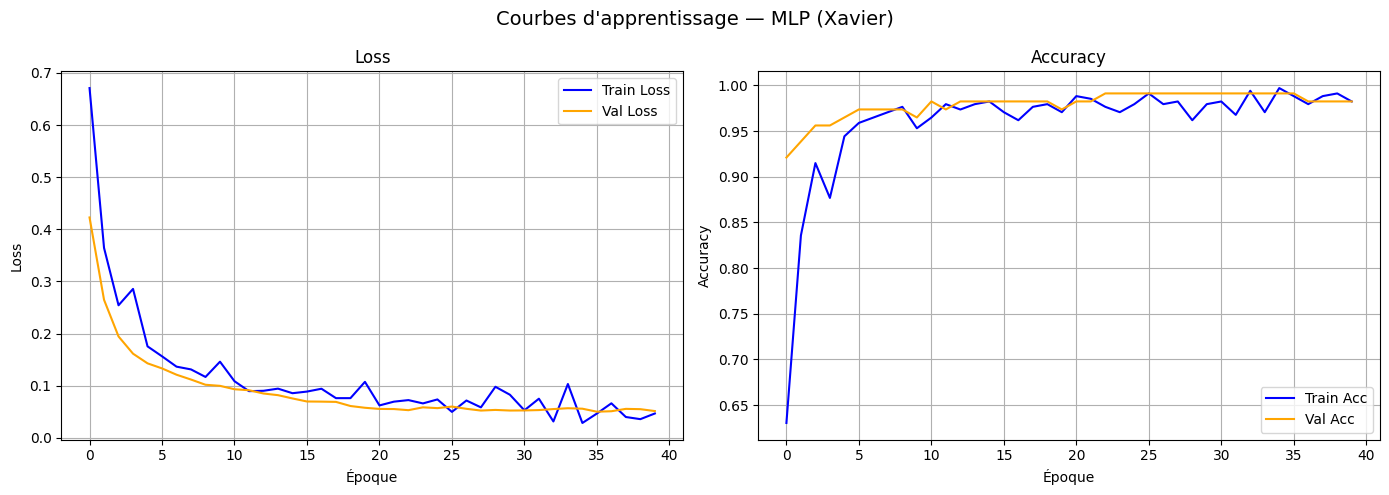

In [ ]:
# ============================================================
# ÉTAPE 8 — Courbes d'apprentissage
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage — MLP (Xavier)", fontsize=14)

# --- Courbe Loss ---
axes[0].plot(historique['train_loss'], label='Train Loss', color='blue')
axes[0].plot(historique['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title("Loss")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# --- Courbe Accuracy ---
axes[1].plot(historique['train_acc'], label='Train Acc', color='blue')
axes[1].plot(historique['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Entraînement gaussienne...
  → 47 époques | Acc: 0.9649
Entraînement constante...
  → 66 époques | Acc: 0.9561
Entraînement xavier...
  → 37 époques | Acc: 0.9474

=== TABLEAU COMPARATIF ===

Stratégie         Accuracy   F1-Score     Recall  Précision    Époques
-----------------------------------------------------------------
gaussienne          0.9649     0.9718     0.9583     0.9857         47
constante           0.9561     0.9645     0.9444     0.9855         66
xavier              0.9474     0.9571     0.9306     0.9853         37


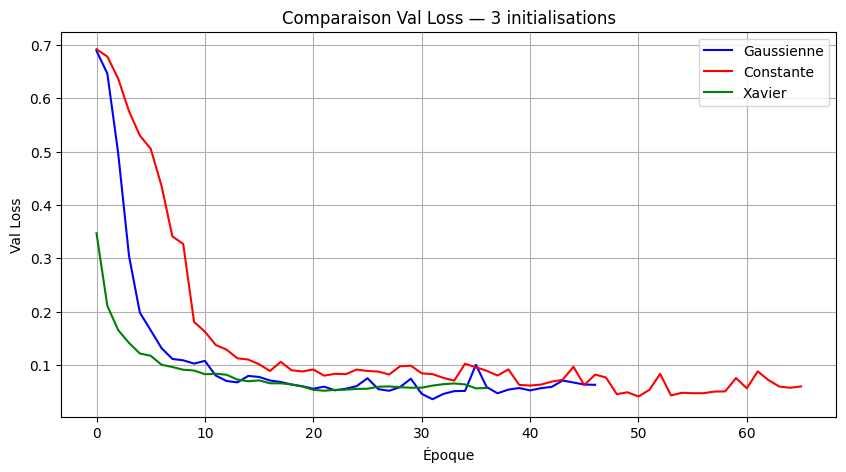

In [ ]:
# ============================================================
# COMPARAISON 3 INITIALISATIONS — TOUT EN UN
# ============================================================

resultats = {}

for strategie in ['gaussienne', 'constante', 'xavier']:
    print(f"Entraînement {strategie}...")

    model     = initialiser_modele(MLPPersonnalise().to(device), strategie)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', patience=10, factor=0.5)

    hist             = {'val_loss': []}
    meilleure_loss   = float('inf')
    meilleur_state   = None
    patience_counter = 0

    for epoch in range(100):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits      = model(X_batch).squeeze()
                val_loss   += criterion(logits, y_batch).item()
                preds       = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == y_batch).sum().item()

        val_loss /= len(val_loader)
        hist['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < meilleure_loss:
            meilleure_loss   = val_loss
            meilleur_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 15:
            break

    # Évaluation sur test
    model.load_state_dict(meilleur_state)
    model.eval()
    with torch.no_grad():
        preds_test = (torch.sigmoid(model(X_test_t).squeeze()) > 0.5).float()

    y_pred = preds_test.cpu().numpy()
    y_true = y_test_t.cpu().numpy()

    resultats[strategie] = {
        'val_loss' : hist['val_loss'],
        'accuracy' : accuracy_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'epochs'   : len(hist['val_loss'])
    }
    print(f"  → {len(hist['val_loss'])} époques | Acc: {resultats[strategie]['accuracy']:.4f}")

# --- Tableau comparatif ---
print("\n=== TABLEAU COMPARATIF ===\n")
print(f"{'Stratégie':<15} {'Accuracy':>10} {'F1-Score':>10} {'Recall':>10} {'Précision':>10} {'Époques':>10}")
print("-" * 65)
for nom, res in resultats.items():
    print(f"{nom:<15} {res['accuracy']:>10.4f} {res['f1']:>10.4f} "
          f"{res['recall']:>10.4f} {res['precision']:>10.4f} {res['epochs']:>10}")

# --- Graphique ---
plt.figure(figsize=(10, 5))
couleurs = {'gaussienne': 'blue', 'constante': 'red', 'xavier': 'green'}
for nom, res in resultats.items():
    plt.plot(res['val_loss'], label=nom.capitalize(), color=couleurs[nom])
plt.title("Comparaison Val Loss — 3 initialisations")
plt.xlabel("Époque")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# PROJET DEEP LEARNING — PARTIE II : CNN
# Dataset : Fashion-MNIST
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Fixer les seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

# Classes Fashion-MNIST
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Nombre de classes : {len(CLASS_NAMES)}")
print(f"Classes : {CLASS_NAMES}")

Device utilisé : cpu
Nombre de classes : 10
Classes : ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 34.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.9MB/s]


=== INFOS DATASET ===
Train      : 51,000 images
Validation : 9,000 images
Test       : 10,000 images
Taille image : 28×28 pixels (niveaux de gris)
Nombre de classes : 10


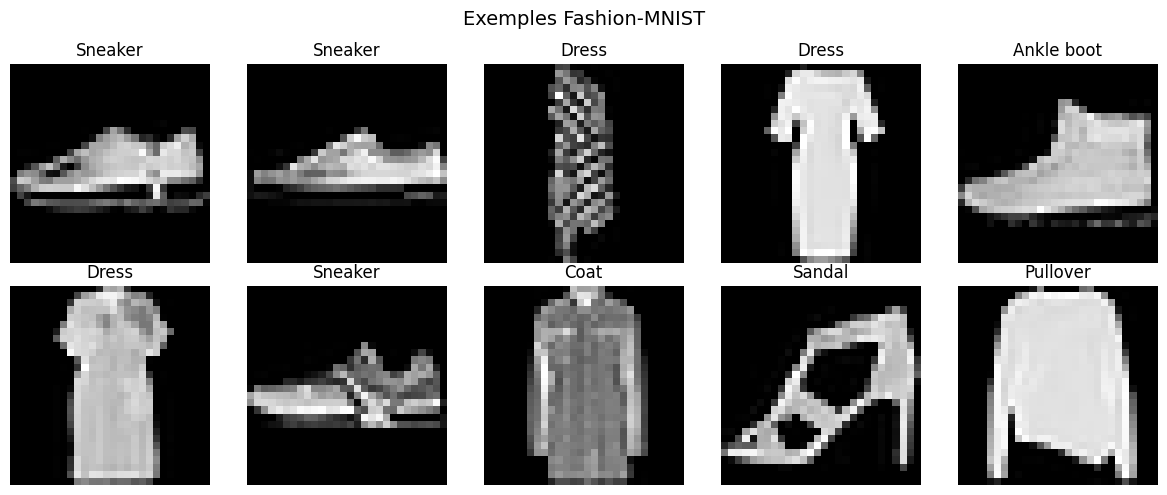

In [ ]:
# ============================================================
# ÉTAPE 2 — Chargement du dataset Fashion-MNIST
# ============================================================

# Transformation : normalisation des pixels [0,255] → [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean=0.5, std=0.5
])

# Téléchargement automatique
train_val_data = datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform)
test_data      = datasets.FashionMNIST(root='./data', train=False,
                                        download=True, transform=transform)

# Séparation Train / Validation (85% / 15%)
train_size = int(0.85 * len(train_val_data))
val_size   = len(train_val_data) - train_size
train_data, val_data = torch.utils.data.random_split(
    train_val_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print("=== INFOS DATASET ===")
print(f"Train      : {len(train_data):,} images")
print(f"Validation : {len(val_data):,} images")
print(f"Test       : {len(test_data):,} images")
print(f"Taille image : 28×28 pixels (niveaux de gris)")
print(f"Nombre de classes : 10")

# --- Visualisation de quelques images ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exemples Fashion-MNIST", fontsize=14)

images, labels = next(iter(train_loader))

for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ÉTAPE 3 — Calculs manuels de convolution et pooling
# ============================================================

print("=" * 60)
print("FORMULES IMPORTANTES")
print("=" * 60)

print("""
1. TAILLE DE SORTIE APRÈS CONVOLUTION :
   sortie = (entrée - kernel + 2×padding) / stride + 1

2. TAILLE DE SORTIE APRÈS POOLING :
   sortie = (entrée - kernel) / stride + 1
""")

print("=" * 60)
print("EXEMPLES CALCULÉS")
print("=" * 60)

# Exemple 1 : Image 28x28, Conv 3x3, padding=1, stride=1
entree, kernel, padding, stride = 28, 3, 1, 1
sortie = (entree - kernel + 2*padding) // stride + 1
print(f"\nEx 1 — Conv(3×3, padding=1, stride=1) sur image {entree}×{entree}")
print(f"  sortie = ({entree} - {kernel} + 2×{padding}) / {stride} + 1 = {sortie}×{sortie}")

# Exemple 2 : Après MaxPool 2x2, stride=2
entree2, kernel2, stride2 = 28, 2, 2
sortie2 = (entree2 - kernel2) // stride2 + 1
print(f"\nEx 2 — MaxPool(2×2, stride=2) sur feature map {entree2}×{entree2}")
print(f"  sortie = ({entree2} - {kernel2}) / {stride2} + 1 = {sortie2}×{sortie2}")

# Exemple 3 : Conv(3x3, padding=0, stride=1) sur 14x14
entree3, kernel3, padding3, stride3 = 14, 3, 0, 1
sortie3 = (entree3 - kernel3 + 2*padding3) // stride3 + 1
print(f"\nEx 3 — Conv(3×3, padding=0, stride=1) sur {entree3}×{entree3}")
print(f"  sortie = ({entree3} - {kernel3} + 2×{padding3}) / {stride3} + 1 = {sortie3}×{sortie3}")

print("""
RÉSUMÉ :
- padding=0 → l'image RÉDUIT après convolution
- padding=1 (avec kernel 3×3) → l'image GARDE la même taille  ✅
- MaxPool(2×2) → divise toujours la taille par 2
""")

print("=" * 60)
print("ÉVOLUTION DES DIMENSIONS DANS NOTRE CNN")
print("=" * 60)
print("""
Entrée          : 1  × 28 × 28
Après Conv1     : 32 × 28 × 28  (padding=1 → même taille)
Après MaxPool1  : 32 × 14 × 14  (divisé par 2)
Après Conv2     : 64 × 14 × 14  (padding=1 → même taille)
Après MaxPool2  : 64 × 7  × 7   (divisé par 2)
Après Flatten   : 64 × 7 × 7 = 3136 valeurs
Après FC1       : 128 neurones
Après FC2       : 10 neurones (1 par classe)
""")

FORMULES IMPORTANTES

1. TAILLE DE SORTIE APRÈS CONVOLUTION :
   sortie = (entrée - kernel + 2×padding) / stride + 1

2. TAILLE DE SORTIE APRÈS POOLING :
   sortie = (entrée - kernel) / stride + 1

EXEMPLES CALCULÉS

Ex 1 — Conv(3×3, padding=1, stride=1) sur image 28×28
  sortie = (28 - 3 + 2×1) / 1 + 1 = 28×28

Ex 2 — MaxPool(2×2, stride=2) sur feature map 28×28
  sortie = (28 - 2) / 2 + 1 = 14×14

Ex 3 — Conv(3×3, padding=0, stride=1) sur 14×14
  sortie = (14 - 3 + 2×0) / 1 + 1 = 12×12

RÉSUMÉ :
- padding=0 → l'image RÉDUIT après convolution
- padding=1 (avec kernel 3×3) → l'image GARDE la même taille  ✅
- MaxPool(2×2) → divise toujours la taille par 2

ÉVOLUTION DES DIMENSIONS DANS NOTRE CNN

Entrée          : 1  × 28 × 28
Après Conv1     : 32 × 28 × 28  (padding=1 → même taille)
Après MaxPool1  : 32 × 14 × 14  (divisé par 2)
Après Conv2     : 64 × 14 × 14  (padding=1 → même taille)
Après MaxPool2  : 64 × 7  × 7   (divisé par 2)
Après Flatten   : 64 × 7 × 7 = 3136 valeurs
Après FC1 

Différence max entre implémentation manuelle et PyTorch : 0.000000
→ Résultat identique ✅


/tmp/ipykernel_20891/2590632017.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


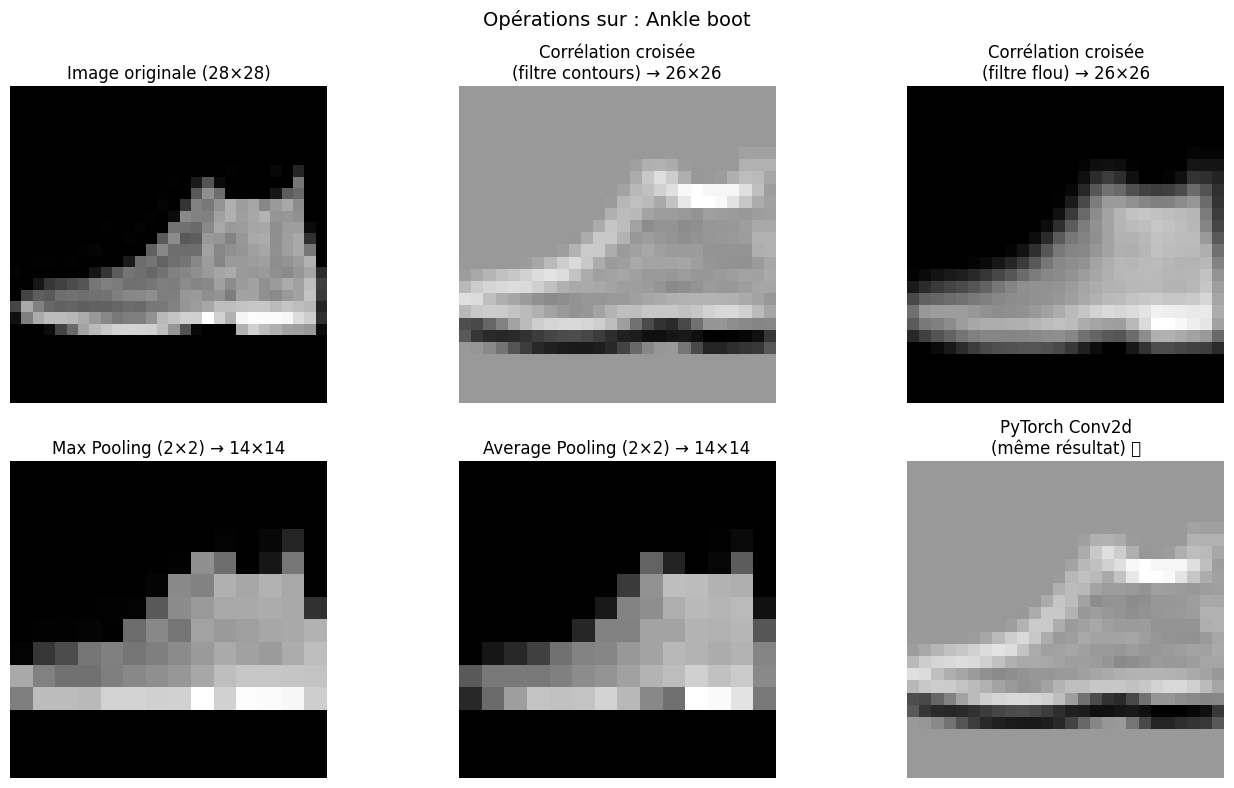


=== RÉSUMÉ DES TAILLES ===
Image originale       : (28, 28)
Après corrélation     : (26, 26)
Après max pooling     : (14, 14)
Après average pooling : (14, 14)


In [ ]:
# ============================================================
# ÉTAPE 4 — Implémentation manuelle : corrélation croisée 2D,
#            max-pooling et average-pooling
# ============================================================

# ── 1. Corrélation croisée 2D ──────────────────────────────
def correlation_croisee_2d(image, kernel):
    H, W   = image.shape
    kH, kW = kernel.shape
    H_out = H - kH + 1
    W_out = W - kW + 1
    sortie = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            region = image[i:i+kH, j:j+kW]
            sortie[i, j] = np.sum(region * kernel)
    return sortie


# ── 2. Max Pooling 2D ──────────────────────────────────────
def max_pooling_2d(image, taille=2, stride=2):
    H, W = image.shape
    H_out = (H - taille) // stride + 1
    W_out = (W - taille) // stride + 1
    sortie = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            region = image[i*stride:i*stride+taille,
                          j*stride:j*stride+taille]
            sortie[i, j] = np.max(region)
    return sortie


# ── 3. Average Pooling 2D ──────────────────────────────────
def average_pooling_2d(image, taille=2, stride=2):
    H, W = image.shape
    H_out = (H - taille) // stride + 1
    W_out = (W - taille) // stride + 1
    sortie = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            region = image[i*stride:i*stride+taille,
                          j*stride:j*stride+taille]
            sortie[i, j] = np.mean(region)
    return sortie


# ── Test sur une vraie image Fashion-MNIST ─────────────────
images, labels = next(iter(test_loader))
image_np = images[0].squeeze().numpy()

# Kernels
kernel_contours = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

kernel_flou = np.ones((3, 3), dtype=np.float32) / 9.0

# Appliquer nos fonctions manuelles
image_contours = correlation_croisee_2d(image_np, kernel_contours)
image_flou     = correlation_croisee_2d(image_np, kernel_flou)
image_maxpool  = max_pooling_2d(image_np)
image_avgpool  = average_pooling_2d(image_np)

# ── Comparaison avec PyTorch ────────────────────────────────
img_tensor = images[0].unsqueeze(0)

conv_pytorch = nn.Conv2d(1, 1, kernel_size=3, padding=0, bias=False)
with torch.no_grad():
    conv_pytorch.weight[0, 0] = torch.tensor(kernel_contours)

# Correction : .detach() ajouté ✅
sortie_pytorch = conv_pytorch(img_tensor).squeeze().detach().numpy()

diff = np.abs(image_contours - sortie_pytorch).max()
print(f"Différence max entre implémentation manuelle et PyTorch : {diff:.6f}")
print("→ Résultat identique ✅" if diff < 1e-4 else "→ Différence détectée ⚠️")

# ── Visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f"Opérations sur : {CLASS_NAMES[labels[0].item()]}", fontsize=14)

axes[0,0].imshow(image_np,       cmap='gray'); axes[0,0].set_title("Image originale (28×28)")
axes[0,1].imshow(image_contours, cmap='gray'); axes[0,1].set_title("Corrélation croisée\n(filtre contours) → 26×26")
axes[0,2].imshow(image_flou,     cmap='gray'); axes[0,2].set_title("Corrélation croisée\n(filtre flou) → 26×26")
axes[1,0].imshow(image_maxpool,  cmap='gray'); axes[1,0].set_title("Max Pooling (2×2) → 14×14")
axes[1,1].imshow(image_avgpool,  cmap='gray'); axes[1,1].set_title("Average Pooling (2×2) → 14×14")
axes[1,2].imshow(sortie_pytorch, cmap='gray'); axes[1,2].set_title("PyTorch Conv2d\n(même résultat) ✅")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n=== RÉSUMÉ DES TAILLES ===")
print(f"Image originale       : {image_np.shape}")
print(f"Après corrélation     : {image_contours.shape}")
print(f"Après max pooling     : {image_maxpool.shape}")
print(f"Après average pooling : {image_avgpool.shape}")

In [ ]:
# ============================================================
# ÉTAPE 5 — CNN inspiré de LeNet
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # ── Bloc Convolutif 1 ──
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 1×28×28 → 32×28×28
        self.bn1   = nn.BatchNorm2d(32)

        # ── Bloc Convolutif 2 ──
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32×14×14 → 64×14×14
        self.bn2   = nn.BatchNorm2d(64)

        # ── Bloc Convolutif 3 ──
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64×7×7 → 128×7×7
        self.bn3   = nn.BatchNorm2d(128)

        # ── Pooling ──
        self.pool    = nn.MaxPool2d(2, 2)   # Divise par 2

        # ── Convolution 1×1 (demandée par le prof) ──
        self.conv1x1 = nn.Conv2d(128, 64, kernel_size=1)  # Réduit les canaux

        # ── Couches Fully Connected ──
        # Après 3 MaxPool : 28 → 14 → 7 → 3 (floor)
        # Après conv1x1   : 64 canaux
        # 64 × 3 × 3 = 576
        self.fc1     = nn.Linear(64 * 3 * 3, 256)
        self.fc2     = nn.Linear(256, 128)
        self.fc3     = nn.Linear(128, 10)   # 10 classes

        self.dropout = nn.Dropout(0.5)
        self.relu    = nn.ReLU()

    def forward(self, x):
        # Bloc 1 : Conv → BN → ReLU → Pool
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # → 32×14×14

        # Bloc 2 : Conv → BN → ReLU → Pool
        x = self.pool(self.relu(self.bn2(self.conv2(x))))   # → 64×7×7

        # Bloc 3 : Conv → BN → ReLU → Pool
        x = self.pool(self.relu(self.bn3(self.conv3(x))))   # → 128×3×3

        # Conv 1×1 : réduit les canaux
        x = self.relu(self.conv1x1(x))                      # → 64×3×3

        # Aplatir pour les couches FC
        x = x.view(x.size(0), -1)                           # → 576

        # Couches FC
        x = self.dropout(self.relu(self.fc1(x)))            # → 256
        x = self.dropout(self.relu(self.fc2(x)))            # → 128
        x = self.fc3(x)                                     # → 10
        return x


# Instancier le modèle
cnn_model = CNN().to(device)
print(cnn_model)

# Compter les paramètres
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres : {total_params:,}")

# Vérifier les dimensions avec un batch test
with torch.no_grad():
    test_input  = torch.randn(1, 1, 28, 28).to(device)
    test_output = cnn_model(test_input)
    print(f"Shape entrée  : {test_input.shape}")
    print(f"Shape sortie  : {test_output.shape} → 10 classes ✅")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1x1): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

Nombre total de paramètres : 283,274
Shape entrée  : torch.Size([1, 1, 28, 28])
Shape sortie  : tor

In [ ]:
# ============================================================
# ÉTAPE 6 — Entraînement du CNN
# ============================================================

criterion = nn.CrossEntropyLoss()  # Multi-classe (10 classes)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=3, factor=0.5)

EPOCHS   = 20
historique = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

meilleure_val_loss = float('inf')
patience_counter   = 0
PATIENCE           = 7

print("=== ENTRAÎNEMENT CNN ===\n")

for epoch in range(EPOCHS):

    # ── MODE ENTRAÎNEMENT ──
    cnn_model.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = cnn_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(train_data)

    # ── MODE VALIDATION ──
    cnn_model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits       = cnn_model(X_batch)
            loss         = criterion(logits, y_batch)
            val_loss    += loss.item()
            preds        = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_data)

    scheduler.step(val_loss)

    # ── Sauvegarder le meilleur modèle ──
    if val_loss < meilleure_val_loss:
        meilleure_val_loss = val_loss
        torch.save(cnn_model.state_dict(), 'meilleur_cnn.pth')
        sauvegarde_msg     = " ← sauvegardé ✅"
        patience_counter   = 0
    else:
        sauvegarde_msg   = ""
        patience_counter += 1

    historique['train_loss'].append(train_loss)
    historique['val_loss'].append(val_loss)
    historique['train_acc'].append(train_acc)
    historique['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
          f"{sauvegarde_msg}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping à l'époque {epoch+1}")
        break

print(f"\nEntraînement terminé ! Meilleure Val Loss : {meilleure_val_loss:.4f}")

=== ENTRAÎNEMENT CNN ===

Epoch  1/20 | Train Loss: 0.5393 | Train Acc: 0.8087 | Val Loss: 0.3233 | Val Acc: 0.8854 ← sauvegardé ✅
Epoch  2/20 | Train Loss: 0.3330 | Train Acc: 0.8857 | Val Loss: 0.2900 | Val Acc: 0.8968 ← sauvegardé ✅
Epoch  3/20 | Train Loss: 0.2862 | Train Acc: 0.9005 | Val Loss: 0.2690 | Val Acc: 0.9028 ← sauvegardé ✅
Epoch  4/20 | Train Loss: 0.2572 | Train Acc: 0.9087 | Val Loss: 0.2565 | Val Acc: 0.9036 ← sauvegardé ✅
Epoch  5/20 | Train Loss: 0.2333 | Train Acc: 0.9199 | Val Loss: 0.2449 | Val Acc: 0.9170 ← sauvegardé ✅
Epoch  6/20 | Train Loss: 0.2155 | Train Acc: 0.9251 | Val Loss: 0.2426 | Val Acc: 0.9172 ← sauvegardé ✅
Epoch  7/20 | Train Loss: 0.1964 | Train Acc: 0.9311 | Val Loss: 0.2318 | Val Acc: 0.9182 ← sauvegardé ✅
Epoch  8/20 | Train Loss: 0.1848 | Train Acc: 0.9348 | Val Loss: 0.2452 | Val Acc: 0.9153
Epoch  9/20 | Train Loss: 0.1744 | Train Acc: 0.9383 | Val Loss: 0.2402 | Val Acc: 0.9193
Epoch 10/20 | Train Loss: 0.1645 | Train Acc: 0.9418 | Val 

Meilleur modèle CNN rechargé ✅

=== MÉTRIQUES SUR LE TEST SET ===

Accuracy  : 0.9137
Précision : 0.9146
Recall    : 0.9137
F1-Score  : 0.9139

=== RAPPORT COMPLET ===

              precision    recall  f1-score   support

     T-shirt       0.87      0.84      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.88      0.86      0.87      1000
       Dress       0.89      0.95      0.92      1000
        Coat       0.89      0.84      0.86      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.74      0.78      0.75      1000
     Sneaker       0.97      0.96      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



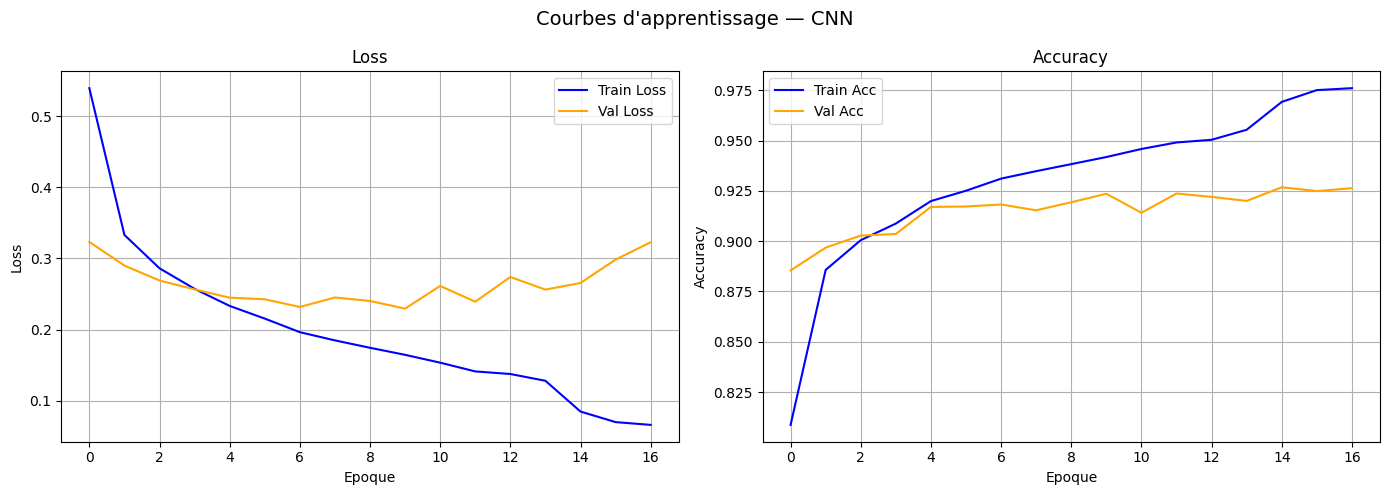

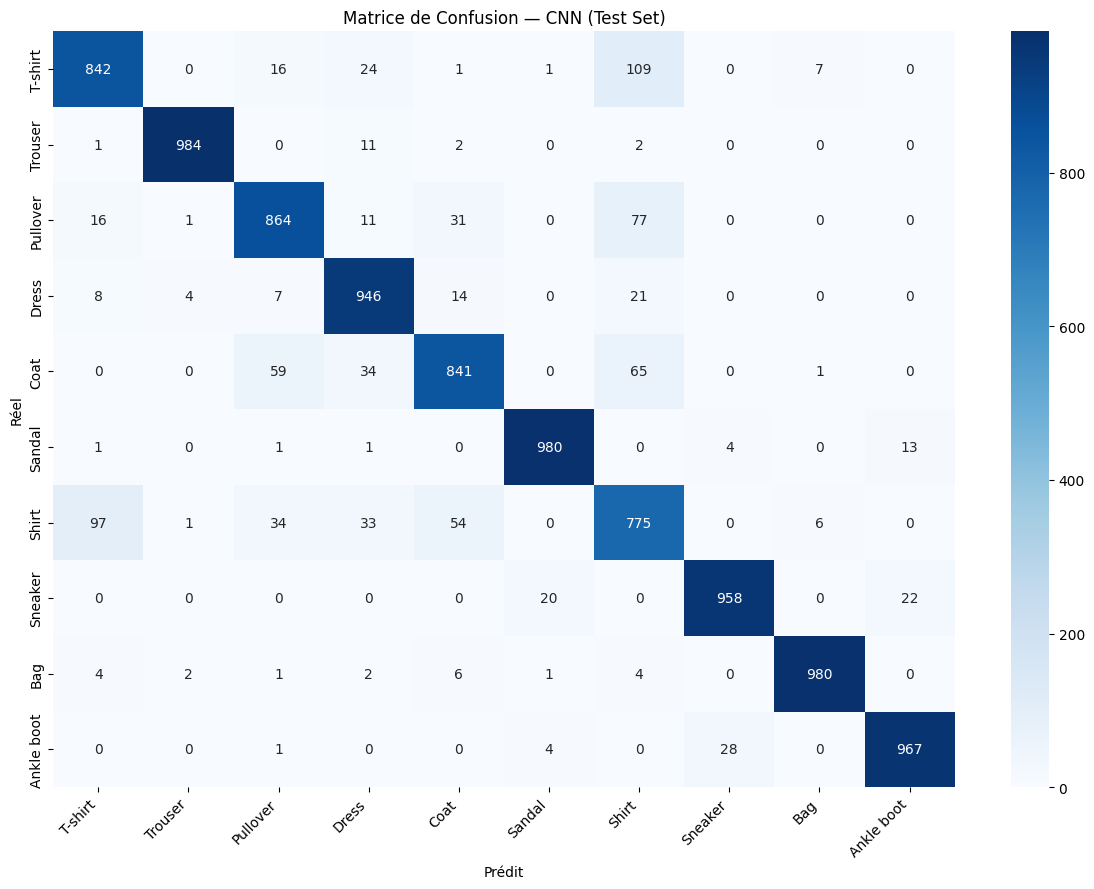

In [ ]:
# ============================================================
# ÉTAPE 7 — Évaluation finale sur le Test Set
# ============================================================

# --- Recharger le meilleur modèle ---
meilleur_cnn = CNN().to(device)
meilleur_cnn.load_state_dict(torch.load('meilleur_cnn.pth'))
meilleur_cnn.eval()
print("Meilleur modèle CNN rechargé ✅\n")

# --- Prédictions sur le test set ---
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = meilleur_cnn(X_batch)
        preds   = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Métriques ---
print("=== MÉTRIQUES SUR LE TEST SET ===\n")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Précision : {precision_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='macro'):.4f}")
print(f"F1-Score  : {f1_score(all_labels, all_preds, average='macro'):.4f}")

print("\n=== RAPPORT COMPLET ===\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# --- Courbes d'apprentissage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage — CNN", fontsize=14)

axes[0].plot(historique['train_loss'], label='Train Loss', color='blue')
axes[0].plot(historique['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(historique['train_acc'], label='Train Acc', color='blue')
axes[1].plot(historique['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Matrice de Confusion ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Matrice de Confusion — CNN (Test Set)")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


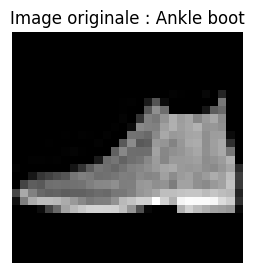

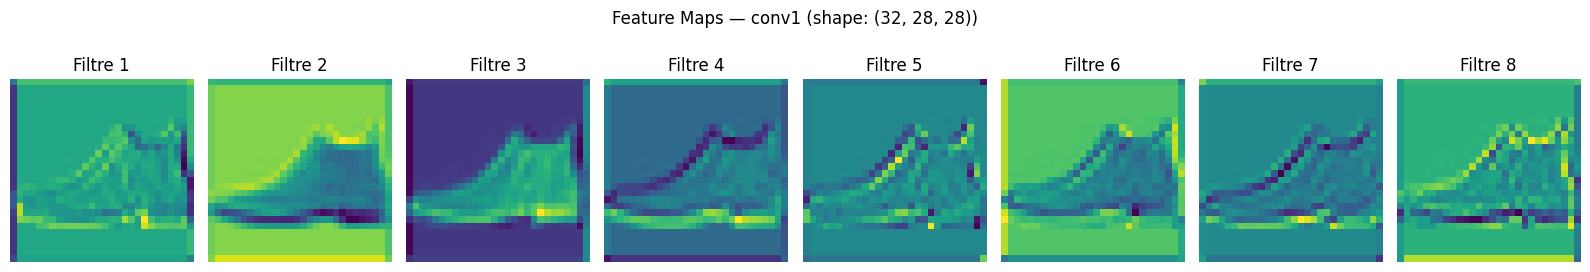

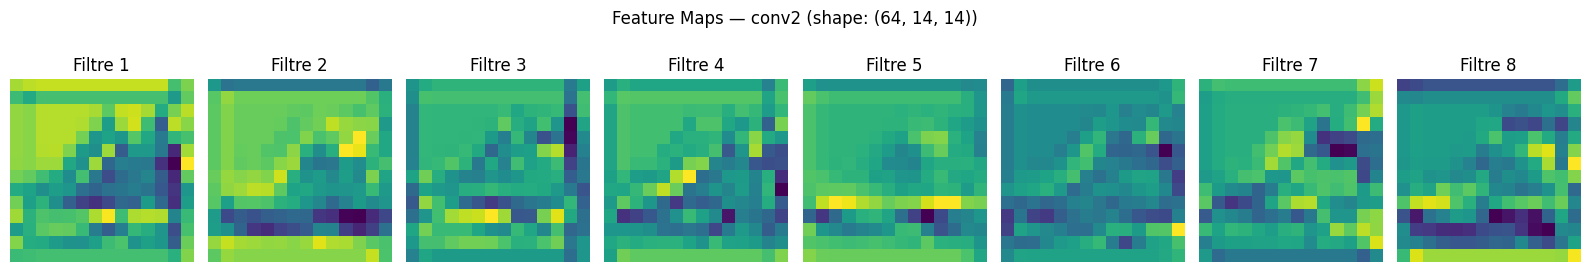

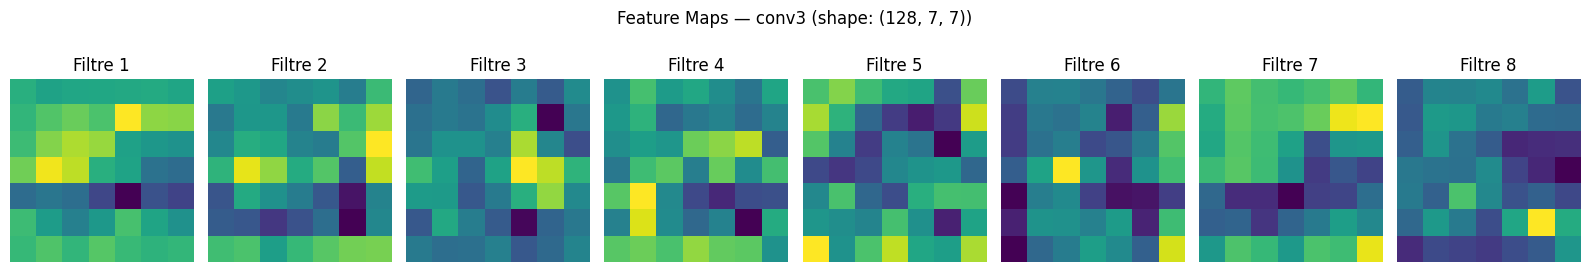

=== INTERPRETATION DES FEATURE MAPS ===

conv1 (32 filtres, 28x28) :
  → Détecte les features de bas niveau : bords, contours, textures simples
  → Les feature maps ressemblent encore à l'image originale

conv2 (64 filtres, 14x14) :
  → Détecte les features de niveau intermédiaire : formes, motifs
  → L'image est plus petite, plus abstraite

conv3 (128 filtres, 7x7) :
  → Détecte les features de haut niveau : parties d'objets
  → Très abstrait, difficile à interpréter visuellement
  → C'est ici que le modèle "reconnaît" le vêtement



In [ ]:
# ============================================================
# ÉTAPE 8 — Visualisation des Feature Maps
# ============================================================

# Prendre une image du test set
images, labels = next(iter(test_loader))
image  = images[0].unsqueeze(0).to(device)  # 1×1×28×28
label  = CLASS_NAMES[labels[0].item()]

# --- Extraire les feature maps après chaque bloc convolutif ---
meilleur_cnn.eval()

feature_maps = {}

def hook_fn(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Enregistrer les hooks sur les couches conv
hook1 = meilleur_cnn.conv1.register_forward_hook(hook_fn('conv1'))
hook2 = meilleur_cnn.conv2.register_forward_hook(hook_fn('conv2'))
hook3 = meilleur_cnn.conv3.register_forward_hook(hook_fn('conv3'))

# Passer l'image dans le modèle
with torch.no_grad():
    _ = meilleur_cnn(image)

# Retirer les hooks
hook1.remove()
hook2.remove()
hook3.remove()

# --- Visualiser l'image originale ---
plt.figure(figsize=(3, 3))
plt.imshow(images[0].squeeze().numpy(), cmap='gray')
plt.title(f"Image originale : {label}")
plt.axis('off')
plt.show()

# --- Visualiser 8 feature maps de chaque couche ---
for nom_couche, fmaps in feature_maps.items():
    n_filtres = min(8, fmaps.shape[1])  # Afficher 8 filtres max
    fig, axes = plt.subplots(1, n_filtres, figsize=(16, 3))
    fig.suptitle(f"Feature Maps — {nom_couche} "
                 f"(shape: {tuple(fmaps.shape[1:])})", fontsize=12)

    for i in range(n_filtres):
        axes[i].imshow(fmaps[0, i].numpy(), cmap='viridis')
        axes[i].set_title(f"Filtre {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("=== INTERPRETATION DES FEATURE MAPS ===")
print("""
conv1 (32 filtres, 28x28) :
  → Détecte les features de bas niveau : bords, contours, textures simples
  → Les feature maps ressemblent encore à l'image originale

conv2 (64 filtres, 14x14) :
  → Détecte les features de niveau intermédiaire : formes, motifs
  → L'image est plus petite, plus abstraite

conv3 (128 filtres, 7x7) :
  → Détecte les features de haut niveau : parties d'objets
  → Très abstrait, difficile à interpréter visuellement
  → C'est ici que le modèle "reconnaît" le vêtement
""")


Entraînement MLP...
  Epoch  5 | Train Acc: 0.8632 | Val Acc: 0.8652
  Epoch 10 | Train Acc: 0.8726 | Val Acc: 0.8786
  Epoch 15 | Train Acc: 0.8854 | Val Acc: 0.8834

=== TABLEAU COMPARATIF MLP vs CNN ===

Modèle       Accuracy   F1-Score     Recall  Précision   Paramètres    Époques
---------------------------------------------------------------------------
MLP            0.8787     0.8777     0.8787     0.8789      243,530         15
CNN            0.9137     0.9139     0.9137     0.9146      283,274         17


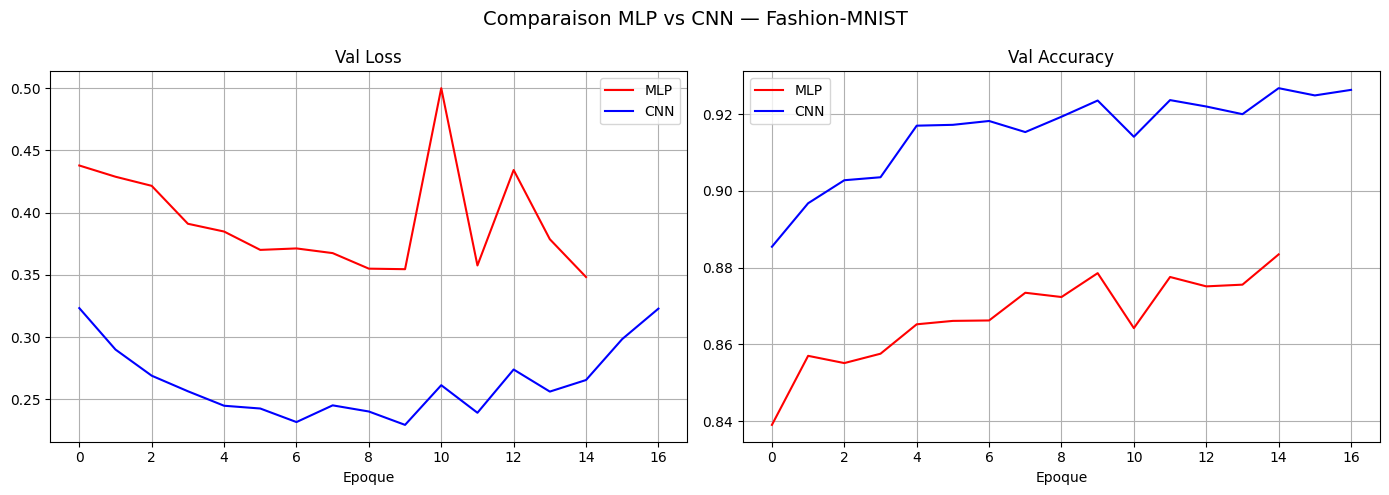

In [ ]:
# ============================================================
# ÉTAPE 9 — Comparaison MLP vs CNN sur Fashion-MNIST
# ============================================================

# ── MLP simple pour images ─────────────────────────────────
class MLPImage(nn.Module):
    def __init__(self):
        super(MLPImage, self).__init__()
        self.reseau = nn.Sequential(
            nn.Flatten(),              # 1×28×28 → 784
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)          # 10 classes
        )

    def forward(self, x):
        return self.reseau(x)


def entrainer_et_evaluer(model, nom, epochs=15, patience=5):
    """Entraîne un modèle et retourne ses métriques"""

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', patience=3, factor=0.5)

    hist             = {'train_loss': [], 'val_loss': [],
                        'train_acc' : [], 'val_acc' : []}
    meilleure_loss   = float('inf')
    meilleur_state   = None
    patience_counter = 0

    print(f"\nEntraînement {nom}...")

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, train_correct = 0.0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item()
            train_correct += (model(X_batch).argmax(1) == y_batch).sum().item()

        train_loss /= len(train_loader)
        train_acc   = train_correct / len(train_data)

        # Validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits       = model(X_batch)
                val_loss    += criterion(logits, y_batch).item()
                val_correct += (logits.argmax(1) == y_batch).sum().item()

        val_loss /= len(val_loader)
        val_acc   = val_correct / len(val_data)

        scheduler.step(val_loss)
        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)

        if val_loss < meilleure_loss:
            meilleure_loss   = val_loss
            meilleur_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if patience_counter >= patience:
            print(f"  Early stopping à l'époque {epoch+1}")
            break

    # Evaluation sur test
    model.load_state_dict(meilleur_state)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch  = X_batch.to(device)
            preds    = model(X_batch).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        'historique' : hist,
        'accuracy'   : accuracy_score(all_labels, all_preds),
        'f1'         : f1_score(all_labels, all_preds, average='macro'),
        'recall'     : recall_score(all_labels, all_preds, average='macro'),
        'precision'  : precision_score(all_labels, all_preds, average='macro'),
        'params'     : sum(p.numel() for p in model.parameters()),
        'epochs'     : len(hist['val_loss'])
    }


# --- Entraîner le MLP ---
mlp_image = MLPImage().to(device)
res_mlp   = entrainer_et_evaluer(mlp_image, "MLP")

# --- Résultats CNN déjà obtenus ---
res_cnn = {
    'accuracy' : accuracy_score(all_labels, all_preds),
    'f1'       : f1_score(all_labels, all_preds, average='macro'),
    'recall'   : recall_score(all_labels, all_preds, average='macro'),
    'precision': precision_score(all_labels, all_preds, average='macro'),
    'params'   : sum(p.numel() for p in meilleur_cnn.parameters()),
    'epochs'   : len(historique['val_loss']),
    'historique': historique
}

# --- Tableau comparatif ---
print("\n=== TABLEAU COMPARATIF MLP vs CNN ===\n")
print(f"{'Modèle':<10} {'Accuracy':>10} {'F1-Score':>10} "
      f"{'Recall':>10} {'Précision':>10} {'Paramètres':>12} {'Époques':>10}")
print("-" * 75)
for nom, res in [('MLP', res_mlp), ('CNN', res_cnn)]:
    print(f"{nom:<10} {res['accuracy']:>10.4f} {res['f1']:>10.4f} "
          f"{res['recall']:>10.4f} {res['precision']:>10.4f} "
          f"{res['params']:>12,} {res['epochs']:>10}")

# --- Graphique comparatif ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison MLP vs CNN — Fashion-MNIST", fontsize=14)

axes[0].plot(res_mlp['historique']['val_loss'], label='MLP', color='red')
axes[0].plot(res_cnn['historique']['val_loss'], label='CNN', color='blue')
axes[0].set_title("Val Loss")
axes[0].set_xlabel("Epoque")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(res_mlp['historique']['val_acc'], label='MLP', color='red')
axes[1].plot(res_cnn['historique']['val_acc'], label='CNN', color='blue')
axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Epoque")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
